Aluno: Lucas Barbosa dos Santos

#Importando os dados do kaggle

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
files.upload()  # Faça upload do seu arquivo kaggle.json
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download nisargchodavadiya/daily-gold-price-20152021-time-series

Dataset URL: https://www.kaggle.com/datasets/nisargchodavadiya/daily-gold-price-20152021-time-series
License(s): other
daily-gold-price-20152021-time-series.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip daily-gold-price-20152021-time-series.zip

Archive:  daily-gold-price-20152021-time-series.zip
replace Gold Price.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Gold Price.csv          


##Importando as bibliotecas

In [ ]:
!pip install "numpy<2" pmdarima

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

##Análise exploratória

In [ ]:
df = pd.read_csv('Gold Price.csv')
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2025-01-06,77149,77309,77542,76545,27160,0.44
1,2025-01-03,76813,77246,78600,76613,60,-0.05
2,2025-01-02,76849,76849,76849,76849,0,0.83
3,2025-01-01,76214,76232,76302,76053,60,-0.02
4,2024-12-31,76232,75680,76970,75572,1920,0.95


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2848 non-null   object 
 1   Price   2848 non-null   int64  
 2   Open    2848 non-null   int64  
 3   High    2848 non-null   int64  
 4   Low     2848 non-null   int64  
 5   Volume  2848 non-null   int64  
 6   Chg%    2848 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 155.9+ KB


In [ ]:
df.isna().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Volume,0
Chg%,0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

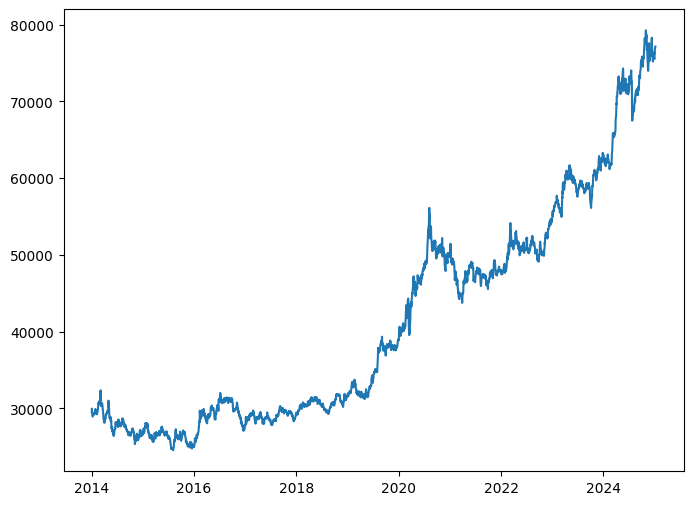

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df['Date'], df['Price']);

In [ ]:
df.set_index("Date", inplace=True)

# Agregando por mês (média)
monthly_df = df.resample("ME").mean()

In [ ]:
monthly_df.head()

,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-31,29386.500000,29372.666667,29511.208333,29241.375000,14714.583333,0.003333
2014-02-28,30184.450000,30096.550000,30294.950000,30004.400000,13341.500000,0.195000
2014-03-31,30100.190476,30083.380952,30353.238095,29840.333333,14437.619048,-0.326667
2014-04-30,29199.521739,29085.956522,29321.478261,28955.608696,8173.478261,0.378696
2014-05-31,28373.636364,28505.000000,28654.090909,28228.772727,12911.818182,-0.597273


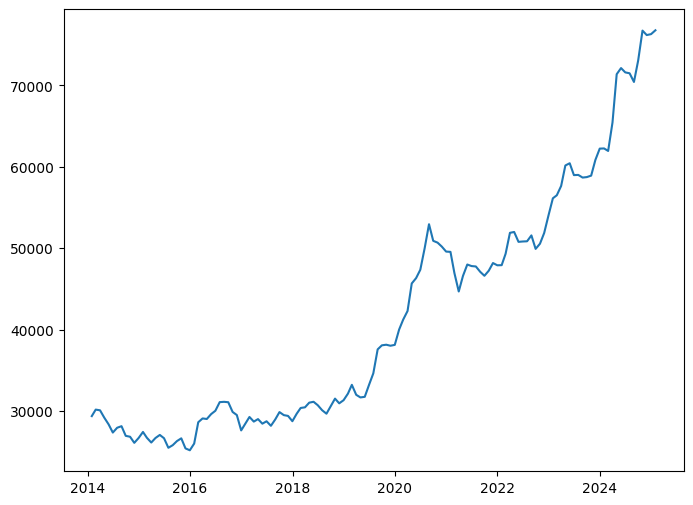

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(monthly_df.index, monthly_df['Price']);

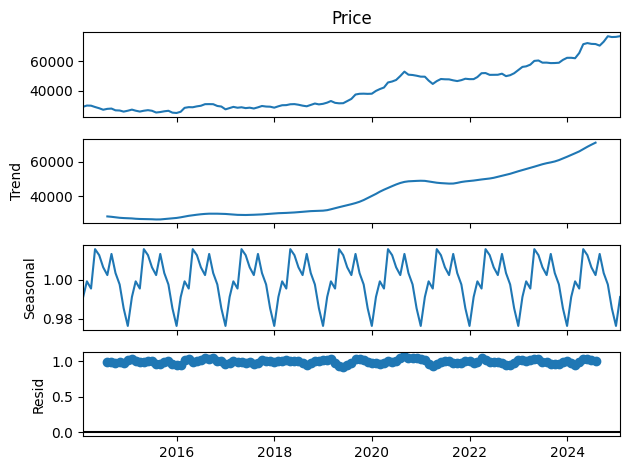

In [ ]:
result = seasonal_decompose(monthly_df['Price'], model='multiplicative', period=12)
result.plot()
plt.show()

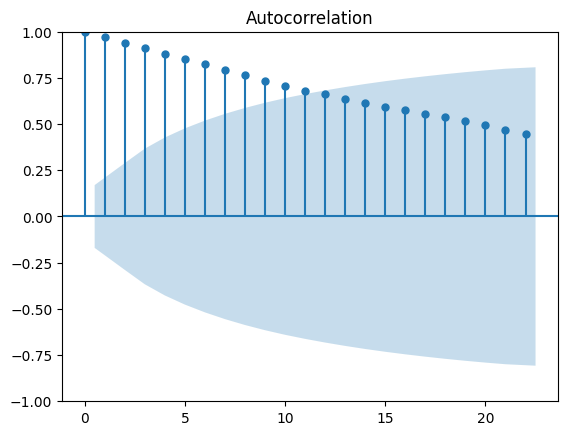

In [ ]:
plot_acf(monthly_df["Price"])
plt.show()

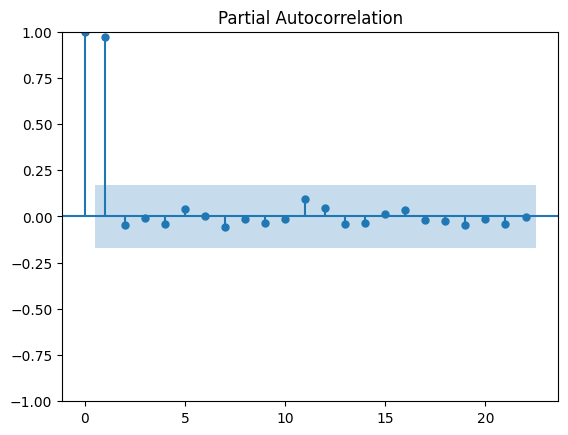

In [ ]:
plot_pacf(monthly_df["Price"])
plt.show()

In [ ]:
def test_stationarity(series):
    # KPSS Test
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
    print(f"KPSS p-value: {kpss_p}")
    if kpss_p < 0.05:
        print("❌ KPSS: Série NÃO é estacionária.")
    else:
        print("✅ KPSS: Série estacionária.")

In [ ]:
test_stationarity(monthly_df['Price'])

KPSS p-value: 0.01
❌ KPSS: Série NÃO é estacionária.


In [ ]:
def differentiate(data: pd.DataFrame | pd.Series, m: int = 1):
  diffs = []
  for t in range(m, len(data)):
    diffs.append(data.values[t] - data.values[t - m])

  return pd.DataFrame({f"Diff(m={m})": diffs})

In [ ]:
df_diff = differentiate(monthly_df["Price"])

In [ ]:
test_stationarity(df_diff)

KPSS p-value: 0.02147699100112839
❌ KPSS: Série NÃO é estacionária.


In [ ]:
df_diff2 = differentiate(df_diff['Diff(m=1)'])

In [ ]:
test_stationarity(df_diff2)

KPSS p-value: 0.1
✅ KPSS: Série estacionária.


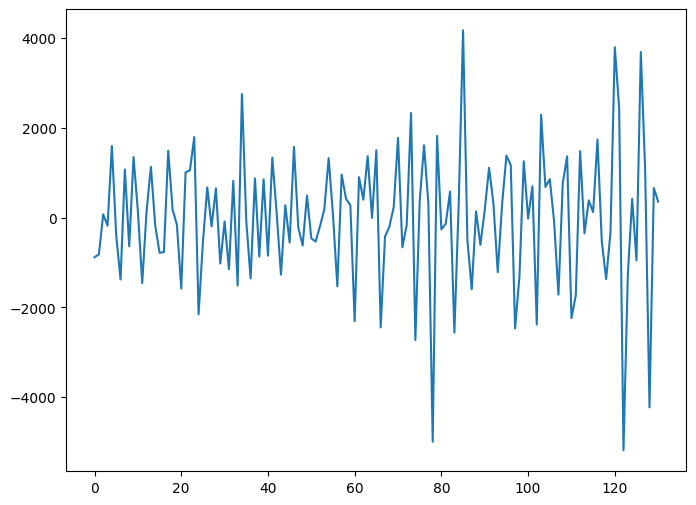

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df_diff2.index, df_diff2['Diff(m=1)'])

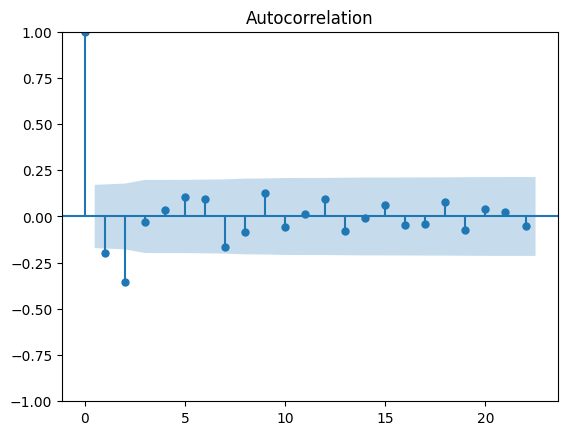

In [ ]:
plot_acf(df_diff2)
plt.show()

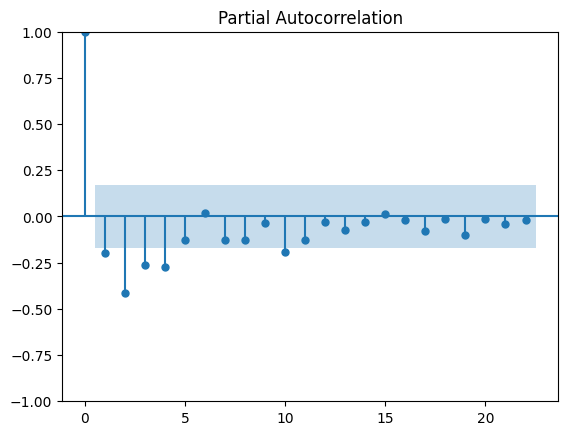

In [ ]:
plot_pacf(df_diff2)
plt.show()

##Treinamento dos modelos

In [ ]:
ts = monthly_df['Price'].values
ts_diff =df_diff2.squeeze().values
test_size = int(len(ts) * 0.2)
train, test = ts[:-test_size], ts[-test_size:]
train_diff, test_diff = ts_diff[:-test_size], ts_diff[-test_size:]

In [ ]:
lag = 10
autoreg_model = AutoReg(train_diff, lags=lag)
ma_model = ARIMA(train_diff, order=[0, 0, lag])
ar_model = ARIMA(train_diff, order=[lag, 0, 0])
arma_model = ARIMA(train_diff, order=[lag, 0, lag])
arima_model = ARIMA(train, order=[lag, 2 , lag])
sarima_model = SARIMAX(
    train,
    order=(5, 2, 5),               # parte não sazonal
    seasonal_order=(1, 2, 1,  12),     # parte sazonal
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [ ]:
autoreg_results = autoreg_model.fit().predict(start=len(train_diff),
                                              end=len(train_diff) + len(test_diff)-1,
                                              dynamic=False)

In [ ]:
ma_results = ma_model.fit().predict(start=len(train_diff),
                                    end=len(train_diff) + len(test_diff) - 1)

In [ ]:
ar_results = ar_model.fit().predict(start=len(train_diff),
                                    end=len(train_diff) + len(test_diff) - 1)

In [ ]:
arma_results = arma_model.fit().predict(start=len(train_diff),
                                    end=len(train_diff) + len(test_diff) - 1)

In [ ]:
arima_results = arima_model.fit().predict(start=len(train),
                                    end=len(train) + len(test) - 1)

In [ ]:
sarima_results = sarima_model.fit().predict(start=len(train),
                                    end=len(train) + len(test) - 1)

<Axes: >

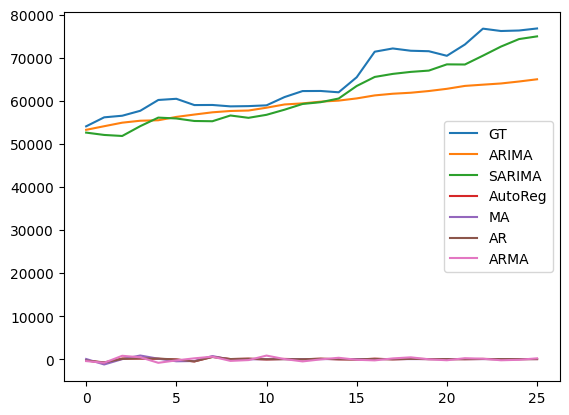

In [ ]:
results = {"GT": test,
           "ARIMA": arima_results,
           "SARIMA": sarima_results,
           "AutoReg": autoreg_results.squeeze(),
           "MA": ma_results,
           "AR": ar_results,
           "ARMA": arma_results}

df_results = pd.DataFrame(results)
df_results.plot()

## Metricas de avaliação

In [ ]:
def mse(gt: any, pred: any) -> float:
    return np.square(gt - pred).mean()

def rmse(gt: any, pred: any) -> float:
    return np.sqrt(mse(gt, pred))

def mae(gt: any, pred: any) -> float:
    return np.abs(gt - pred).mean()

def mape(gt: any, pred: any) -> float:
    # Evita divisão por zero
    gt = np.where(gt == 0, np.finfo(float).eps, gt)
    return (np.abs((gt - pred) / gt).mean()) * 100

def get_metrics(gt: any, pred: any) -> dict:
    metrics = {
        "mae": mae(gt, pred),
        "mse": mse(gt, pred),
        "rmse": rmse(gt, pred),
        "mape": mape(gt, pred)
    }
    return metrics

In [ ]:
autoreg_results = get_metrics(results["GT"], results["AutoReg"])
autoreg_results

{'mae': 64945.98903273904,
 'mse': 4271082490.6329966,
 'rmse': 65353.51934389606,
 'mape': 100.05727971281229}

In [ ]:
ar_results = get_metrics(results["GT"], results["AR"])
ar_results

{'mae': 64947.09537507985,
 'mse': 4271211445.87885,
 'rmse': 65354.50593401231,
 'mape': 100.05915377865837}

In [ ]:
ma_results = get_metrics(results["GT"], results["MA"])
ma_results

{'mae': 64939.35582863814,
 'mse': 4270514087.1655436,
 'rmse': 65349.170516277736,
 'mape': 100.0439669800705}

In [ ]:
arma_results = get_metrics(results["GT"], results["ARMA"])
arma_results

{'mae': 64945.0981954078,
 'mse': 4271516705.5295916,
 'rmse': 65356.84130624423,
 'mape': 100.05025705861993}

In [ ]:
arima_results = get_metrics(results["GT"], results["ARIMA"])
arima_results

{'mae': 5457.48757721794,
 'mse': 48067495.34639967,
 'rmse': 6933.072576167054,
 'mape': 7.814425125405807}

In [ ]:
sarima_results = get_metrics(results["GT"], results["SARIMA"])
sarima_results

{'mae': 3480.603231580829,
 'mse': 14046060.432062242,
 'rmse': 3747.8074166187143,
 'mape': 5.360838414295178}

##AutoArima

In [ ]:
from pmdarima.arima import auto_arima

In [ ]:
model_auto = auto_arima(train, start_p=3, max_p=8,
                       start_q=2,max_q=8,
                       d=2,
                       start_P=0, max_P=8,
                       start_Q=2, max_Q=8,
                       seasonal=True,
                       m=12,
                       D=2,
                       trace=True,
                       information_criterion="aic",
                       stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(3,2,2)(0,2,2)[12]             : AIC=1444.068, Time=6.71 sec
 ARIMA(0,2,0)(0,2,0)[12]             : AIC=1524.967, Time=0.10 sec
 ARIMA(1,2,0)(1,2,0)[12]             : AIC=1509.685, Time=0.66 sec
 ARIMA(0,2,1)(0,2,1)[12]             : AIC=inf, Time=0.87 sec
 ARIMA(3,2,2)(0,2,1)[12]             : AIC=inf, Time=2.72 sec
 ARIMA(3,2,2)(1,2,2)[12]             : AIC=inf, Time=7.70 sec
 ARIMA(3,2,2)(0,2,3)[12]             : AIC=inf, Time=9.90 sec
 ARIMA(3,2,2)(1,2,1)[12]             : AIC=inf, Time=2.91 sec
 ARIMA(3,2,2)(1,2,3)[12]             : AIC=1467.778, Time=10.55 sec
 ARIMA(2,2,2)(0,2,2)[12]             : AIC=inf, Time=4.45 sec
 ARIMA(3,2,1)(0,2,2)[12]             : AIC=inf, Time=4.14 sec
 ARIMA(4,2,2)(0,2,2)[12]             : AIC=inf, Time=7.53 sec
 ARIMA(3,2,3)(0,2,2)[12]             : AIC=1463.370, Time=5.46 sec
 ARIMA(2,2,1)(0,2,2)[12]             : AIC=inf, Time=4.66 sec
 ARIMA(2,2,3)(0,2,2)[12]             : AIC=1460.857, Time=6.80 

In [ ]:
arima_preds = model_auto.predict(len(results["GT"]))

In [ ]:
arima_results = get_metrics(results["GT"], arima_preds)
arima_results

{'mae': 2352.9877649805007,
 'mse': 7760911.654879302,
 'rmse': 2785.841283145776,
 'mape': 3.634129470568786}

<Axes: >

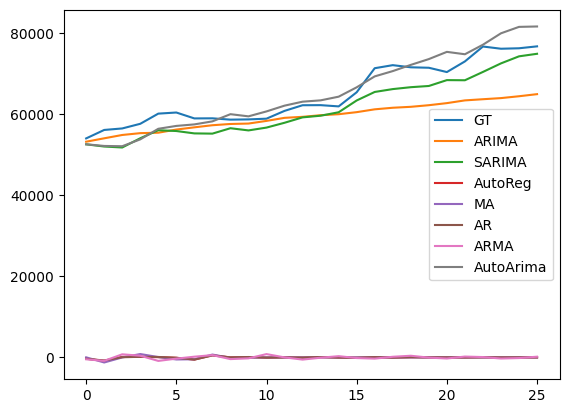

In [ ]:
results["AutoArima"] = arima_preds

df_results = pd.DataFrame(results)
df_results.plot()

In [ ]:
arima_preds = pd.DataFrame(arima_preds, index=monthly_df.index[-len(results["GT"]):],columns=['Price'])

<Axes: xlabel='Date'>

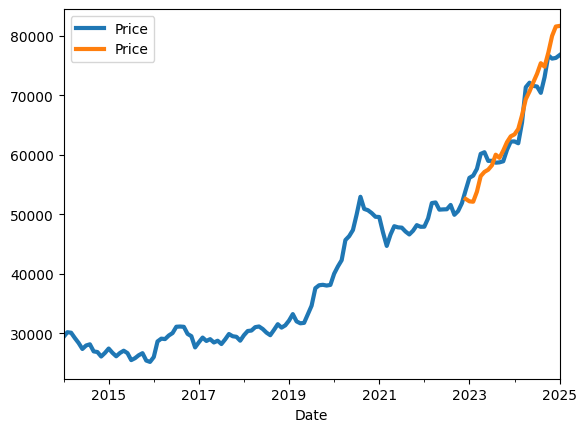

In [ ]:
pd.concat([monthly_df['Price'], arima_preds], axis=1).plot(linewidth=3)

In [ ]:
sarima_pred = sarima_model.fit().predict(start=len(train),
                                    end=len(train) + len(test) - 1)

In [ ]:
sarima_preds = pd.DataFrame(sarima_pred, index=monthly_df.index[-len(results["GT"]):],columns=['Price'])

<Axes: xlabel='Date'>

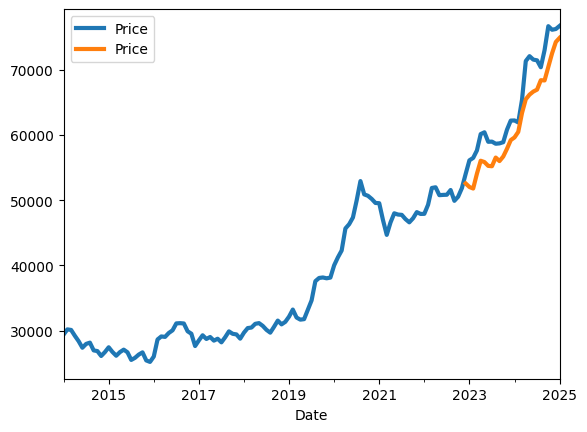

In [ ]:
pd.concat([monthly_df['Price'], sarima_preds], axis=1).plot(linewidth=3)